## 1. Confirm the experiment is trustworthy

In [1]:
from sklift.datasets import fetch_hillstrom
import pandas as pd

# Fetch all three possible outcome columns (conversion, visit, spend) and combine
# them into a single DataFrame, so every later notebook can load one clean file
# instead of re-fetching separately.
bunch_conv = fetch_hillstrom(target_col='conversion')
bunch_visit = fetch_hillstrom(target_col='visit')
bunch_spend = fetch_hillstrom(target_col='spend')

df = bunch_conv['data'].copy()
df['segment'] = bunch_conv['treatment']
df['conversion'] = bunch_conv['target']
df['visit'] = bunch_visit['target']
df['spend'] = bunch_spend['target']

print(df.shape)
df.head()

(64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,conversion,visit,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## 2&3.Understand the population and time window this data represents and Characterize the outcome variable(s)

In [2]:
print(df['segment'].value_counts())
print(df['conversion'].value_counts(normalize=True))
print(df['visit'].value_counts(normalize=True))

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64
conversion
0    0.990969
1    0.009031
Name: proportion, dtype: float64
visit
0    0.853219
1    0.146781
Name: proportion, dtype: float64


## 4. Compute the naive treatment effect (ATE) as a benchmark

In [3]:
df.groupby('segment')['conversion'].mean()

segment
Mens E-Mail      0.012531
No E-Mail        0.005726
Womens E-Mail    0.008837
Name: conversion, dtype: float64

Mens E-Mail: 1.253% conversion vs. 0.573% control → about 2.19x the control rate (a ~119% relative lift).

Womens E-Mail: 0.884% conversion vs. 0.573% control → about 1.54x the control rate (a ~54% relative lift).

## 5. Audit data quality and feature distributions

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   conversion       64000 non-null  int64  
 10  visit            64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB


In [5]:
df.describe(include='all')

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,conversion,visit,spend
count,64000.000000,64000,64000.000000,64000.000000,64000.000000,64000,64000.000000,64000,64000,64000.000000,64000.000000,64000.000000
unique,NaN,7,NaN,NaN,NaN,3,NaN,3,3,NaN,NaN,NaN
top,NaN,1) $0 - $100,NaN,NaN,NaN,Surburban,NaN,Web,Womens E-Mail,NaN,NaN,NaN
freq,NaN,22970,NaN,NaN,NaN,28776,NaN,28217,21387,NaN,NaN,NaN
mean,5.763734,NaN,242.085656,0.551031,0.549719,NaN,0.502250,NaN,NaN,0.009031,0.146781,1.050908
std,3.507592,NaN,256.158608,0.497393,0.497526,NaN,0.499999,NaN,NaN,0.094604,0.353890,15.036448
min,1.000000,NaN,29.990000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000
25%,2.000000,NaN,64.660000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000
50%,6.000000,NaN,158.110000,1.000000,1.000000,NaN,1.000000,NaN,NaN,0.000000,0.000000,0.000000
75%,9.000000,NaN,325.657500,1.000000,1.000000,NaN,1.000000,NaN,NaN,0.000000,0.000000,0.000000


## 6. Check whether individual features relate to the outcome at all

the most recently active customers (0–3 months) convert at 1.24%, dropping steadily to 0.66% for those who've been quiet 9–12 months — roughly double the response rate at the recent end versus the stale end.

In [6]:
print(df.groupby('newbie')['conversion'].mean())
print(df.groupby(pd.cut(df['recency'], bins=[0,3,6,9,12]))['conversion'].mean())

newbie
0    0.010108
1    0.007964
Name: conversion, dtype: float64
recency
(0, 3]     0.012370
(3, 6]     0.007962
(6, 9]     0.007136
(9, 12]    0.006567
Name: conversion, dtype: float64


## 7. Check feature-by-treatment interaction (heterogeneity) — the key finding

In [7]:
pivot_newbie = df.pivot_table(index='newbie', columns='segment', values='conversion', aggfunc='mean')
print(pivot_newbie)

df['recency_band'] = pd.cut(df['recency'], bins=[0,3,6,9,12])
pivot_recency = df.pivot_table(index='recency_band', columns='segment', values='conversion', aggfunc='mean')
print(pivot_recency)

segment  Mens E-Mail  No E-Mail  Womens E-Mail
newbie                                        
0           0.013935   0.007728       0.008660
1           0.011136   0.003740       0.009012
segment       Mens E-Mail  No E-Mail  Womens E-Mail
recency_band                                       
(0, 3]           0.016334   0.009008       0.011755
(3, 6]           0.010486   0.005455       0.007995
(6, 9]           0.011305   0.003405       0.006700
(9, 12]          0.009605   0.002953       0.007078


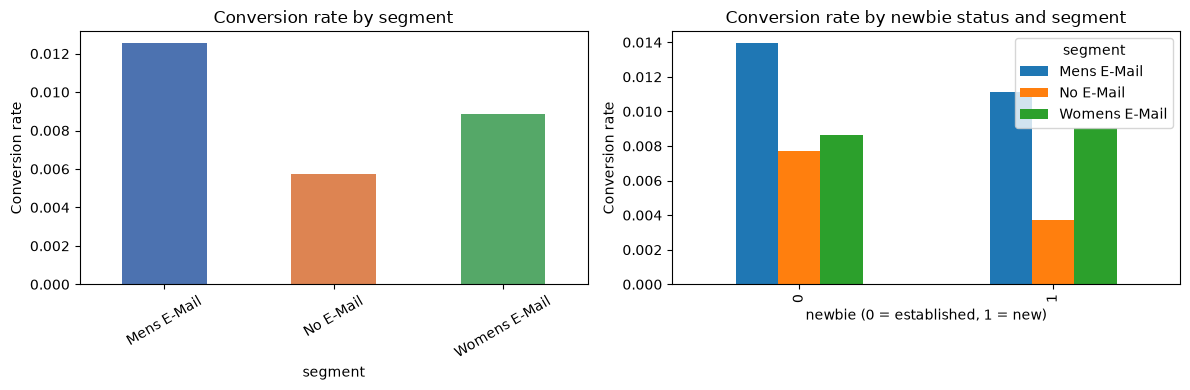

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('segment')['conversion'].mean().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Conversion rate by segment')
axes[0].set_ylabel('Conversion rate')
axes[0].tick_params(axis='x', rotation=30)

pivot_newbie.plot(kind='bar', ax=axes[1])
axes[1].set_title('Conversion rate by newbie status and segment')
axes[1].set_ylabel('Conversion rate')
axes[1].set_xlabel('newbie (0 = established, 1 = new)')

plt.tight_layout()
plt.show()

## 8. Simplify scope, document the choice, and prepare data for modeling

We narrow from three treatment arms to two (Womens E-Mail vs. No Email) because the twin-model (T-learner) uplift approach is built around a single treated-vs-control comparison, and this pair showed the clearest heterogeneity above (the ~6x newbie gap). Mens vs. No Email uses identical code with a different filter and is a good next step to attempt independently once this pipeline works end to end.

We also drop `history_segment` here since it duplicates the same information as `history` (a bucketed vs. continuous version of spend).

In [9]:
df_binary = df[df['segment'].isin(['Womens E-Mail', 'No E-Mail'])].copy()
df_binary['treatment'] = (df_binary['segment'] == 'Womens E-Mail').astype(int)
df_binary = df_binary.drop(columns=['history_segment'])

print(df_binary.shape)
print(df_binary['treatment'].value_counts())
print(df_binary.columns.tolist())

(42693, 13)
treatment
1    21387
0    21306
Name: count, dtype: int64
['recency', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'conversion', 'visit', 'spend', 'recency_band', 'treatment']


In [10]:
import os

os.makedirs('../data/processed', exist_ok=True)
df_binary.to_csv('../data/processed/hillstrom_binary.csv', index=False)
print("Saved columns:", df_binary.columns.tolist())

Saved columns: ['recency', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'conversion', 'visit', 'spend', 'recency_band', 'treatment']
